In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd


In [2]:
# not set up yet
import wandb

super_secret_API_key = "d1678741bcd8eb1d90ca26aa8f2bf079256ac391"

wandb.login(key=super_secret_API_key)

WANDB_PROJECT = "ZNEUS_project2_cnn"
WANDB_ENTITY = None  # getpass.getuser()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\bizon\_netrc
wandb: Currently logged in as: bizon-mimi (bizon-mimi-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.randn(1).cuda())

print("CUDA available:", torch.cuda.is_available())


print("Current device index:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0))


2.9.1+cu130
13.0
tensor([-1.0904], device='cuda:0')
CUDA available: True
Current device index: 0
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
from dataclasses import dataclass, asdict


@dataclass
class Config:
    CSV_FILE: str = "images/sports.csv"
    ROOT_DIR: str = "images"
    BATCH_SIZE: int = 64
    NUM_EPOCHS: int = 100
    LEARNING_RATE: float = 0.001
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = -1
    PIN_MEMORY: bool = True
    DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    PATIENCE: int = 20
    LR_SCHEDULER: str = "cosine"


config = Config()

In [5]:
from pathlib import Path

train_dir = Path("images/train")

# List all immediate subfolders in train (assuming each is a class)
class_folders = [f for f in train_dir.iterdir() if f.is_dir()]
num_classes = len(class_folders)

# Count all images across folders
image_count = 0
for folder in class_folders:
    img_files = list(folder.glob("*.jpg"))
    image_count += len(img_files)

print(f"Number of class folders: {num_classes}")
print(f"Total number of images: {image_count}")

Number of class folders: 100
Total number of images: 13492


In [7]:
# import os
# from pathlib import Path
# from collections import Counter
# from PIL import Image

# train_dir = Path("images/train")
# class_names = [f.name for f in train_dir.iterdir() if f.is_dir()]

# # Count images per class
# class_img_counts = {}
# img_dims = Counter()

# for class_name in class_names:
#     class_path = train_dir / class_name
#     img_files = list(class_path.glob("*.jpg"))
#     class_img_counts[class_name] = len(img_files)
#     # Optionally gather image shape stats
#     for img_file in img_files:
#         try:
#             with Image.open(img_file) as img:
#                 img_dims[img.size] += 1  # img.size is (width, height)
#         except Exception as e:
#             print(f"Corrupted image: {img_file}")

# print("Class image counts:")
# for k, v in class_img_counts.items():
#     print(f"{k}: {v}")

# print("\nMost common image dimensions:")
# for dim, count in img_dims.most_common(5):
#     print(f"{dim}: {count}")

In [122]:
non_jpg_files = {}

for class_folder in train_dir.iterdir():
    if class_folder.is_dir():
        files = [
            f
            for f in class_folder.iterdir()
            if f.is_file() and f.suffix.lower() != ".jpg"
        ]
        if files:
            non_jpg_files[class_folder.name] = [f.name for f in files]

if non_jpg_files:
    print("Non-JPG files found in the following folders:")
    for folder, files in non_jpg_files.items():
        print(f"{folder}: {files}")
else:
    print("All files are JPG images.")

All files are JPG images.


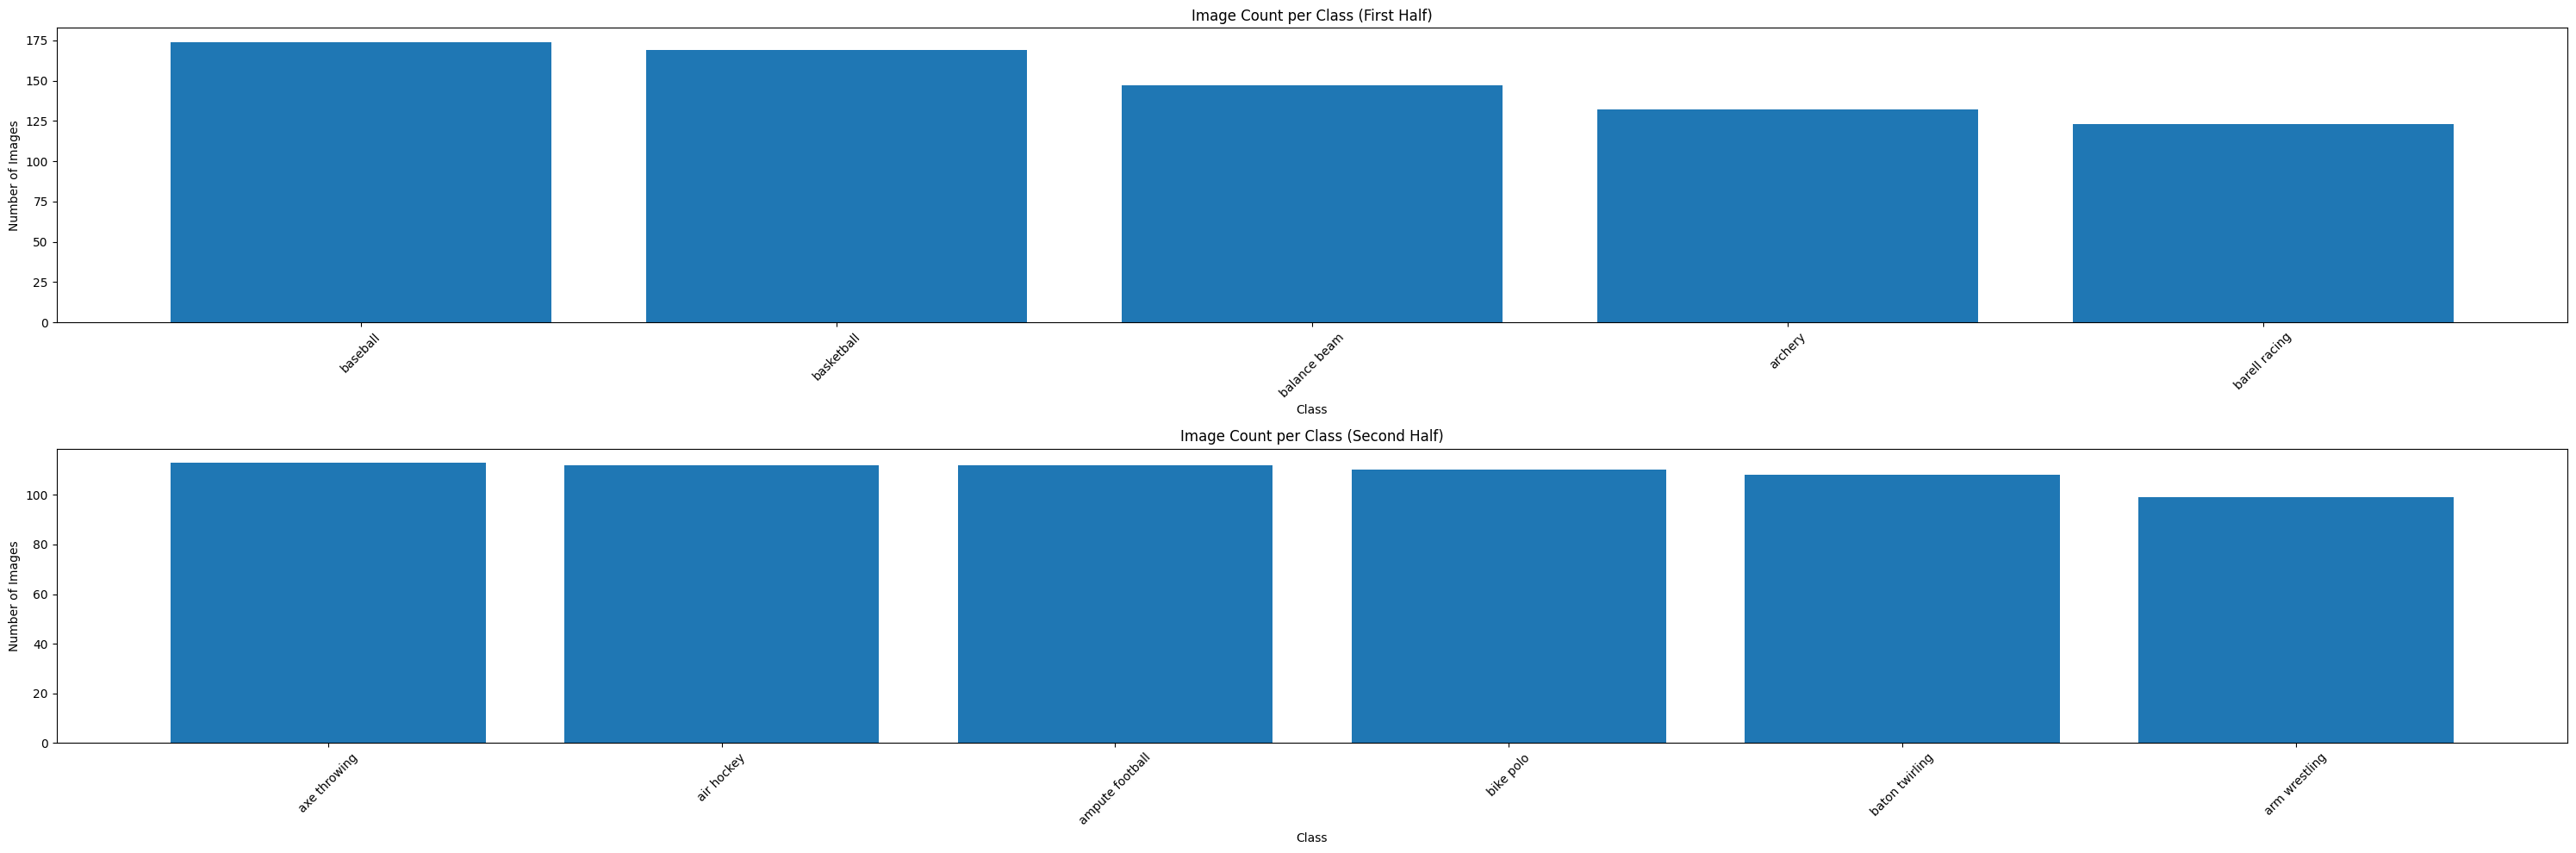

In [123]:
import matplotlib.pyplot as plt

classes = list(class_img_counts.keys())
counts = list(class_img_counts.values())

# Combine classes and counts into a list of tuples
class_count_pairs = sorted(zip(classes, counts), key=lambda x: x[1], reverse=True)

# Split the sorted pairs into two halves
midpoint = len(class_count_pairs) // 2
classes1, counts1 = (
    [pair[0] for pair in class_count_pairs[:midpoint]],
    [pair[1] for pair in class_count_pairs[:midpoint]],
)
classes2, counts2 = (
    [pair[0] for pair in class_count_pairs[midpoint:]],
    [pair[1] for pair in class_count_pairs[midpoint:]],
)

fig, axs = plt.subplots(2, 1, figsize=(30, 10))

axs[0].bar(classes1, counts1)
axs[0].set_title("Image Count per Class (First Half)")
axs[0].set_xlabel("Class")
axs[0].set_ylabel("Number of Images")
axs[0].set_xticks(range(len(classes1)))
axs[0].set_xticklabels(classes1, rotation=45)

axs[1].bar(classes2, counts2)
axs[1].set_title("Image Count per Class (Second Half)")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Number of Images")
axs[1].set_xticks(range(len(classes2)))
axs[1].set_xticklabels(classes2, rotation=45)

plt.tight_layout()
plt.show()

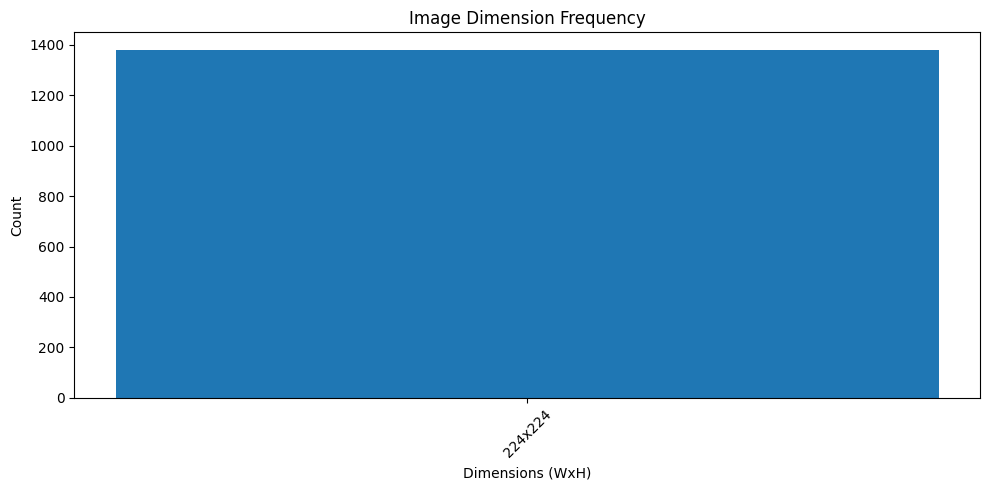

In [124]:
dims = [f"{w}x{h}" for (w, h) in img_dims.keys()]
counts_dim = list(img_dims.values())

plt.figure(figsize=(10, 5))
plt.bar(dims, counts_dim)
plt.title("Image Dimension Frequency")
plt.xlabel("Dimensions (WxH)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels):
        super(CustomCNN, self).__init__()
        # 1
        self.conv1 = nn.Conv2d(
            in_channels=in_channels, out_channels=32, kernel_size=(3, 3), padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 2
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=(3, 3), padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 3
        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=(3, 3), padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.flatten = nn.Flatten()
        # self.dropout1 = nn.Dropout(0.25)

        self.lin1 = nn.Linear(128 * 4 * 4, 256)
        self.bn4 = nn.BatchNorm1d(256)
        # self.dropout2 = nn.Dropout(0.5)
        self.lin2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.adaptive_pool(x)

        x = self.flatten(x)
        # x = self.dropout1(x)

        x = self.lin1(x)
        x = self.bn4(x)
        x = F.relu(x)
        # x = self.dropout2(x)

        x = self.lin2(x)
        return x


class ImprovedCustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3, dropout_p=0.2):
        super(ImprovedCustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        # pooling
        self.pool = nn.MaxPool2d(2, 2)

        # global pooling to compress spatial dims
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        # classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        # Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Global pool -> flatten -> classifier
        x = self.global_pool(x)  # -> (B, 128, 1, 1)
        x = self.flatten(x)  # -> (B, 128)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [7]:
SPORT_CATEGORIES = {
    "vehicles": [
        "bike polo",
        "formula 1 racing",
        "hydroplane racing",
        "motorcycle racing",
        "nascar racing",
        "rollerblade racing",
        "sidecar racing",
        "snowmobile racing",
        "track bicycle",
        "wheelchair racing",
    ],
    "summer": [
        "archery",
        "axe throwing",
        "barell racing",
        "baseball",
        "basketball",
        "cricket",
        "croquet",
        "disc golf",
        "field hockey",
        "frisbee",
        "golf",
        "hammer throw",
        "high jump",
        "hurdles",
        "javelin",
        "lacrosse",
        "pole vault",
        "shot put",
        "tennis",
        "tug of war",
        "ultimate",
    ],
    "winter": [
        "bobsled",
        "curling",
        "figure skating men",
        "figure skating pairs",
        "figure skating women",
        "giant slalom",
        "hockey",
        "ice climbing",
        "ice yachting",
        "luge",
        "mushing",
        "ski jumping",
        "snow boarding",
        "speed skating",
    ],
    "water": [
        "canoe slamon",
        "fly fishing",
        "hydroplane racing",
        "rowing",
        "sailboat racing",
        "surfing",
        "swimming",
        "water cycling",
        "water polo",
    ],
    "indoor": [
        "air hockey",
        "shuffleboard",
        "balance beam",
        "billiards",
        "bowling",
        "cheerleading",
        "jai alai",
        "parallel bar",
        "pole dancing",
        "pommel horse",
        "rings",
        "table tennis",
        "uneven bars",
        "volleyball",
        "weightlifting",
        "wheelchair basketball",
    ],
    "outdoor": [
        "ampute football",
        "baton twirling",
        "bmx",
        "bull riding",
        "bungee jumping",
        "chuckwagon racing",
        "disc golf",
        "football",
        "gaga",
        "hang gliding",
        "harness racing",
        "horse jumping",
        "horse racing",
        "horseshoe pitching",
        "jousting",
        "log rolling",
        "pole climbing",
        "polo",
        "rock climbing",
        "roller derby",
        "rugby",
        "sky surfing",
        "skydiving",
        "steer wrestling",
        "trapeze",
        "wingsuit flying",
    ],
    "combat": [
        "arm wrestling",
        "boxing",
        "fencing",
        "judo",
        "olympic wrestling",
        "sumo wrestling",
    ],
}
LABEL_TO_CATEGORY = {}

for category, sports in SPORT_CATEGORIES.items():
    for sport in sports:
        LABEL_TO_CATEGORY[sport] = category

len(LABEL_TO_CATEGORY)
LABEL_TO_CATEGORY

{'bike polo': 'vehicles',
 'formula 1 racing': 'vehicles',
 'hydroplane racing': 'water',
 'motorcycle racing': 'vehicles',
 'nascar racing': 'vehicles',
 'rollerblade racing': 'vehicles',
 'sidecar racing': 'vehicles',
 'snowmobile racing': 'vehicles',
 'track bicycle': 'vehicles',
 'wheelchair racing': 'vehicles',
 'archery': 'summer',
 'axe throwing': 'summer',
 'barell racing': 'summer',
 'baseball': 'summer',
 'basketball': 'summer',
 'cricket': 'summer',
 'croquet': 'summer',
 'disc golf': 'outdoor',
 'field hockey': 'summer',
 'frisbee': 'summer',
 'golf': 'summer',
 'hammer throw': 'summer',
 'high jump': 'summer',
 'hurdles': 'summer',
 'javelin': 'summer',
 'lacrosse': 'summer',
 'pole vault': 'summer',
 'shot put': 'summer',
 'tennis': 'summer',
 'tug of war': 'summer',
 'ultimate': 'summer',
 'bobsled': 'winter',
 'curling': 'winter',
 'figure skating men': 'winter',
 'figure skating pairs': 'winter',
 'figure skating women': 'winter',
 'giant slalom': 'winter',
 'hockey': 

In [8]:
class SportsDataset(Dataset):
    def __init__(self, csv_file, root_dir, dataset_type, transform=None):
        df = pd.read_csv(csv_file).copy()
        df["category"] = df["labels"].map(LABEL_TO_CATEGORY)

        self.df = df[df["data set"] == dataset_type].reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

        # SPORT classes
        self.sport_classes = sorted(self.df["labels"].unique())
        self.sport_to_idx = {cls: idx for idx, cls in enumerate(self.sport_classes)}

        # CATEGORY classes
        self.category_classes = sorted(self.df["category"].unique())
        self.category_to_idx = {
            cls: idx for idx, cls in enumerate(self.category_classes)
        }

        # ADD THIS: Build sport_classes_per_category
        self.sport_classes_per_category = {}
        for category in self.category_classes:
            # Get all unique sports that belong to this category in the dataset
            sports_in_cat = self.df[self.df["category"] == category]["labels"].unique()
            self.sport_classes_per_category[category] = sorted(sports_in_cat)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["filepaths"])
        image = Image.open(img_path).convert("RGB")

        sport_label = self.sport_to_idx[row["labels"]]
        category_label = self.category_to_idx[row["category"]]

        if self.transform:
            image = self.transform(image)

        return image, category_label, sport_label


In [9]:
train_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# trainset = SportsDataset("images/sports.csv", "images", "train", train_transform)
# validset = SportsDataset("images/sports.csv", "images", "valid", test_transform)
# testset = SportsDataset("images/sports.csv", "images", "test", test_transform)

# trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
# validloader = DataLoader(validset, batch_size=32, shuffle=False)
# testloader = DataLoader(testset, batch_size=32, shuffle=False)

# print(f"Train dataset size: {len(trainset)}")
# print(f"Valid dataset size: {len(validset)}")
# print(f"Test dataset size: {len(testset)}")

trainset = SportsDataset("images/sports.csv", "images", "train", train_transform)
print(trainset.df.category.unique())
trainset.sport_classes_per_category

['indoor' 'outdoor' 'summer' 'combat' 'vehicles' 'winter' 'water']


{'combat': ['arm wrestling',
  'boxing',
  'fencing',
  'judo',
  'olympic wrestling',
  'sumo wrestling'],
 'indoor': ['air hockey',
  'balance beam',
  'billiards',
  'bowling',
  'cheerleading',
  'jai alai',
  'parallel bar',
  'pole dancing',
  'pommel horse',
  'rings',
  'shuffleboard',
  'table tennis',
  'uneven bars',
  'volleyball',
  'weightlifting',
  'wheelchair basketball'],
 'outdoor': ['ampute football',
  'baton twirling',
  'bmx',
  'bull riding',
  'bungee jumping',
  'chuckwagon racing',
  'disc golf',
  'football',
  'gaga',
  'hang gliding',
  'harness racing',
  'horse jumping',
  'horse racing',
  'horseshoe pitching',
  'jousting',
  'log rolling',
  'pole climbing',
  'polo',
  'rock climbing',
  'roller derby',
  'rugby',
  'sky surfing',
  'skydiving',
  'steer wrestling',
  'trapeze',
  'wingsuit flying'],
 'summer': ['archery',
  'axe throwing',
  'barell racing',
  'baseball',
  'basketball',
  'cricket',
  'croquet',
  'field hockey',
  'frisbee',
  'go

In [10]:
# RGB intenzita
# import matplotlib.pyplot as plt
# import numpy as np
# from tqdm import tqdm


# def analyze_rgb_intensity(dataset, classes):
#     """
#     Analyze RGB intensity distribution across the dataset
#     """
#     rgb_means = {"R": [], "G": [], "B": []}

#     print("Analyzing RGB intensities...")
#     for idx in tqdm(range(len(dataset))):
#         image, _ = dataset[idx]

#         # If image is normalized, denormalize it first
#         if image.min() < 0:  # Check if normalized
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         rgb_means["R"].append(image[0].mean().item())
#         rgb_means["G"].append(image[1].mean().item())
#         rgb_means["B"].append(image[2].mean().item())

#     # Plot RGB distribution
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     colors = ["red", "green", "blue"]
#     channels = ["R", "G", "B"]

#     for ax, color, channel in zip(axes, colors, channels):
#         ax.hist(rgb_means[channel], bins=50, color=color, alpha=0.7, edgecolor="black")
#         ax.set_xlabel(f"{channel} Intensity")
#         ax.set_ylabel("Frequency")
#         ax.set_title(f"{channel} Channel Distribution")
#         ax.axvline(
#             np.mean(rgb_means[channel]),
#             color="black",
#             linestyle="--",
#             label=f"Mean: {np.mean(rgb_means[channel]):.3f}",
#         )
#         ax.legend()

#     plt.tight_layout()
#     plt.savefig("rgb_intensity_distribution.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     return rgb_means


# def compute_average_images_per_class(dataset, classes):
#     """
#     Compute and visualize average image for each class
#     """
#     # Initialize accumulators for each class
#     class_sums = {cls: torch.zeros(3, 64, 64) for cls in classes}
#     class_counts = {cls: 0 for cls in classes}

#     print("Computing average images per class...")
#     for idx in tqdm(range(len(dataset))):
#         image, label = dataset[idx]
#         class_name = classes[label]

#         # Denormalize if needed
#         if image.min() < 0:
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         class_sums[class_name] += image
#         class_counts[class_name] += 1

#     # Compute averages
#     average_images = {}
#     for cls in classes:
#         average_images[cls] = class_sums[cls] / class_counts[cls]

#     # Visualize average images
#     num_classes = len(classes)
#     cols = 5
#     rows = (num_classes + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
#     axes = axes.flatten() if num_classes > 1 else [axes]

#     for idx, cls in enumerate(classes):
#         avg_img = average_images[cls].permute(1, 2, 0).numpy()
#         avg_img = np.clip(avg_img, 0, 1)  # Ensure values are in [0, 1]

#         axes[idx].imshow(avg_img)
#         axes[idx].set_title(f"{cls}\n(n={class_counts[cls]})", fontsize=10)
#         axes[idx].axis("off")

#     # Hide extra subplots
#     for idx in range(num_classes, len(axes)):
#         axes[idx].axis("off")

#     plt.tight_layout()
#     plt.savefig("average_images_per_class.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     return average_images, class_counts


# def plot_rgb_by_class(dataset, classes):
#     """
#     Plot RGB intensity distribution for each class
#     """
#     class_rgb = {cls: {"R": [], "G": [], "B": []} for cls in classes}

#     print("Analyzing RGB by class...")
#     for idx in tqdm(range(len(dataset))):
#         image, label = dataset[idx]
#         class_name = classes[label]

#         # Denormalize if needed
#         if image.min() < 0:
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         class_rgb[class_name]["R"].append(image[0].mean().item())
#         class_rgb[class_name]["G"].append(image[1].mean().item())
#         class_rgb[class_name]["B"].append(image[2].mean().item())

#     # Plot
#     num_classes = len(classes)
#     cols = 3
#     rows = (num_classes + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
#     axes = axes.flatten() if num_classes > 1 else [axes]

#     for idx, cls in enumerate(classes):
#         ax = axes[idx]

#         # Create histogram for each channel
#         ax.hist(class_rgb[cls]["R"], bins=30, alpha=0.5, label="Red", color="red")
#         ax.hist(class_rgb[cls]["G"], bins=30, alpha=0.5, label="Green", color="green")
#         ax.hist(class_rgb[cls]["B"], bins=30, alpha=0.5, label="Blue", color="blue")

#         ax.set_xlabel("Intensity")
#         ax.set_ylabel("Frequency")
#         ax.set_title(f"{cls}")
#         ax.legend()

#     # Hide extra subplots
#     for idx in range(num_classes, len(axes)):
#         axes[idx].axis("off")

#     plt.tight_layout()
#     plt.savefig("rgb_by_class.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     # Print statistics
#     print("\nRGB Statistics by Class:")
#     print("-" * 70)
#     for cls in classes:
#         r_mean = np.mean(class_rgb[cls]["R"])
#         g_mean = np.mean(class_rgb[cls]["G"])
#         b_mean = np.mean(class_rgb[cls]["B"])
#         print(f"{cls:20} | R: {r_mean:.3f} | G: {g_mean:.3f} | B: {b_mean:.3f}")


# # 1. RGB Intensity Distribution (overall)
# rgb_stats = analyze_rgb_intensity(trainset, trainset.classes)

# # 2. Average images per class
# avg_images, counts = compute_average_images_per_class(trainset, trainset.classes)

# # 3. RGB distribution by class
# plot_rgb_by_class(trainset, trainset.classes)

In [11]:
class CategoryOnlyDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, category, sport = self.base[idx]
        return image, category


In [12]:
train_base = SportsDataset(
    config.CSV_FILE, "images", "train", transform=train_transform
)
valid_base = SportsDataset(config.CSV_FILE, "images", "valid", transform=test_transform)
test_base = SportsDataset(config.CSV_FILE, "images", "test", transform=test_transform)

trainset_cat = CategoryOnlyDataset(train_base)
validset_cat = CategoryOnlyDataset(valid_base)
testset_cat = CategoryOnlyDataset(test_base)

trainloader_cat = DataLoader(trainset_cat, batch_size=64, shuffle=True)
validloader_cat = DataLoader(validset_cat, batch_size=64)
testloader_cat = DataLoader(testset_cat, batch_size=64)

model = CustomCNN(num_classes=len(train_base.category_classes), in_channels=3)
model = model.to(config.DEVICE)


model_improved = ImprovedCustomCNN(
    num_classes=len(train_base.category_classes), in_channels=3
)
model_improved = model_improved.to(config.DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [13]:
import os


def train(
    name,
    model,
    testloader,
    trainloader,
    validloader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=config.NUM_EPOCHS,
    patience=config.PATIENCE,
):
    # Initialize wandb
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=name,
        config={
            "epochs": epochs,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "architecture": model.__class__.__name__,
        },
    )

    # Optional: watch the model for gradients
    wandb.watch(model, criterion, log="all", log_freq=100)

    best_loss = 0
    best_epoch = 0
    best_accuracy = 0
    print(50 * "-", "training model {name}".format(name=name), 50 * "-")
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        # Create models directory if it doesn't exist
        models_dir = "./models"
        os.makedirs(models_dir, exist_ok=True)

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(trainloader.dataset)

        # ---- validation ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(validloader.dataset)

        scheduler.step()
        test_accuracy = test(model, testloader, device)
        # Check for early stopping
        if best_accuracy <= test_accuracy:
            best_accuracy = test_accuracy
        # save best model
        if val_loss < best_loss or best_accuracy <= test_accuracy:
            best_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), "./models/{name}".format(name=name))
            print("  → Saved best model")
        # Log metrics to wandb
        if epoch - best_epoch >= patience:
            print("Early stopping at epoch", epoch)
            break
        wandb.log(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "test_accuracy": test_accuracy,
                "patience": (epoch - best_epoch),
            }
        )

        print(
            f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
        )

    print("Training finished!")
    wandb.finish()
    print("run stats saved to wandb")
    return test_accuracy


def test(model, testloader, device):
    model.eval()
    correct = 0
    total = 0
    print("testing initiated")
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy


In [173]:
import torchvision.models as models
import torch.nn as nn


def create_resnet18(num_classes, pretrained=True):
    # Load pretrained ResNet18
    if pretrained:
        model = models.resnet18(weights="IMAGENET1K_V1")
    else:
        model = models.resnet18(weights=None)

    # Replace the final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


# Create the model with the correct number of classes
resnet_model = create_resnet18(
    num_classes=len(train_base.category_classes), pretrained=False
)
resnet_model = resnet_model.to(config.DEVICE)

# Create NEW optimizer and scheduler for ResNet
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(
    resnet_model.parameters(), lr=0.001, weight_decay=1e-4
)
scheduler_resnet = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_resnet, T_max=20
)

# Train the model
train(
    name="category_classifier_resnet18",
    model=resnet_model,
    testloader=testloader_cat,
    trainloader=trainloader_cat,
    validloader=validloader_cat,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    scheduler=scheduler_resnet,
    device=config.DEVICE,
    epochs=config.NUM_EPOCHS,
)

-------------------------------------------------- training model category_classifier_resnet18 --------------------------------------------------
Test Accuracy: 0.3580
  → Saved best model
Epoch 0 | Train Loss: 1.5937 | Val Loss: 1.5760
Test Accuracy: 0.4220
  → Saved best model
Epoch 1 | Train Loss: 1.4600 | Val Loss: 1.4689
Test Accuracy: 0.2600
Epoch 2 | Train Loss: 1.3855 | Val Loss: 1.9463
Test Accuracy: 0.4000
Epoch 3 | Train Loss: 1.3492 | Val Loss: 1.4825
Test Accuracy: 0.4020
Epoch 4 | Train Loss: 1.2999 | Val Loss: 1.5958
Test Accuracy: 0.4840
  → Saved best model
Epoch 5 | Train Loss: 1.2658 | Val Loss: 1.3197
Test Accuracy: 0.4160
Epoch 6 | Train Loss: 1.2272 | Val Loss: 1.6326
Test Accuracy: 0.5140
  → Saved best model
Epoch 7 | Train Loss: 1.1831 | Val Loss: 1.2288
Test Accuracy: 0.5820
  → Saved best model
Epoch 8 | Train Loss: 1.1416 | Val Loss: 1.1110
Test Accuracy: 0.6280
  → Saved best model
Epoch 9 | Train Loss: 1.1067 | Val Loss: 1.0547
Test Accuracy: 0.6100
  → Sa

OSError: [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\bizon\\Desktop\\skola\\5.semester\\ZNEUS\\projekt1\\AB_zneus_01\\models\\category_classifier_resnet18' -> 'C:\\Users\\bizon\\Desktop\\skola\\5.semester\\ZNEUS\\projekt1\\AB_zneus_01\\wandb\\run-20251203_211949-eu29gu95\\files\\models\\category_classifier_resnet18'

In [ ]:
train(
    name="category_classifier_v1",
    model=model,
    testloader=testloader_cat,
    trainloader=trainloader_cat,
    validloader=validloader_cat,
    criterion=criterion,
    optimizer=optimizer,
    device=config.DEVICE,
    epochs=config.NUM_EPOCHS,
    scheduler=scheduler,
)

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▂▂▂▃▃▄▅▅▆▆▇▇▇██
patience,▁▂▁▁▁▁▁▁▂▁▁▂▃▃▁▂▃▃▄▁▂▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▁▄▄▅▆▆▇▆▇█▇████▇█████▆█▇█▇▆▆█▇
train_loss,█▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▂▂▁▂▁▁▁▁▁
val_loss,██▅▄▄▃▃▂▃▂▁▁▁▁▁▁▂▂▂▁▁▁▂▂▂▁▂▂▃▂▂
epoch,30
learning_rate,0.00098
patience,9
test_accuracy,0.658
train_loss,0.9186


-------------------------------------------------- training model category_classifier_v1_custom --------------------------------------------------


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [23]:
class SportDatasetForCategory(Dataset):
    """Returns only sports from a specific category"""

    def __init__(self, base_dataset, category_name):
        self.base = base_dataset
        self.indices = []
        self.sports_in_category = []

        # Find all images in this category
        for idx in range(len(base_dataset)):
            image, cat_label, sport_label = base_dataset[idx]
            cat = base_dataset.category_classes[cat_label]

            if cat == category_name:
                self.indices.append(idx)
                sport = base_dataset.sport_classes[sport_label]
                if sport not in self.sports_in_category:
                    self.sports_in_category.append(sport)

        self.sports_in_category.sort()
        self.sport_to_idx = {s: i for i, s in enumerate(self.sports_in_category)}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, _, sport_label = self.base[real_idx]

        # Convert to local sport index
        sport_name = self.base.sport_classes[sport_label]
        local_sport_idx = self.sport_to_idx[sport_name]

        return image, local_sport_idx


def train_models_per_category(train_base, valid_base, test_base, config, device):
    """
    Simple function that trains one CNN per category
    Returns dictionary of trained models
    """
    import os

    os.makedirs("./models", exist_ok=True)

    trained_models = {}
    results = {}

    for category in train_base.category_classes:
        print(f"\n{'=' * 60}")
        print(f"Training model for: {category}")
        print(f"{'=' * 60}")

        # Create datasets for this category
        train_cat = SportDatasetForCategory(train_base, category)
        valid_cat = SportDatasetForCategory(valid_base, category)
        test_cat = SportDatasetForCategory(test_base, category)

        if len(train_cat) < 10:
            print(f"Skipping {category}: not enough data")
            continue

        print(f"Sports in {category}: {len(train_cat.sports_in_category)}")
        print(f"Training samples: {len(train_cat)}")

        # Create dataloaders
        train_loader = DataLoader(train_cat, batch_size=32, shuffle=True)
        valid_loader = DataLoader(valid_cat, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_cat, batch_size=32, shuffle=False)
        print("created data loaders")
        # Create model
        num_sports = len(train_cat.sports_in_category)
        model = CustomCNN(num_classes=num_sports, in_channels=3).to(device)

        # Train
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        print("criterion, optimizer and scheduler initialized\nBeggining to train")

        test_acc = train(
            name=f"sport_classifier_{category}_100_epochs",
            model=model,
            testloader=test_loader,
            trainloader=train_loader,
            validloader=valid_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            epochs=config.NUM_EPOCHS,
            patience=config.PATIENCE,
        )

        # Save results
        trained_models[category] = model
        results[category] = {
            "num_sports": num_sports,
            "sports": train_cat.sports_in_category,
            "test_accuracy": test_acc,
        }

    # Print summary
    print(f"\n{'=' * 60}")
    print("TRAINING COMPLETE - SUMMARY")
    print(f"{'=' * 60}")
    for cat, info in results.items():
        print(
            f"{cat:15s}: {info['num_sports']:2d} sports, Acc: {info['test_accuracy']:.4f}"
        )

    return trained_models, results

In [24]:
sport_models, results = train_models_per_category(
    train_base=train_base,
    valid_base=valid_base,
    test_base=test_base,
    config=config,
    device=config.DEVICE,
)


Training model for: combat
Sports in combat: 6
Training samples: 800
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_combat_100_epochs --------------------------------------------------
testing initiated
Test Accuracy: 0.6000
  → Saved best model
Epoch 0 | Train Loss: 1.3154 | Val Loss: 0.9619
testing initiated
Test Accuracy: 0.5000
  → Saved best model
Epoch 1 | Train Loss: 0.9995 | Val Loss: 0.9028
testing initiated
Test Accuracy: 0.6667
  → Saved best model
Epoch 2 | Train Loss: 0.8377 | Val Loss: 0.4884
testing initiated
Test Accuracy: 0.6333
Epoch 3 | Train Loss: 0.7988 | Val Loss: 0.5790
testing initiated
Test Accuracy: 0.7000
Epoch 4 | Train Loss: 0.7308 | Val Loss: 0.4929
testing initiated
Test Accuracy: 0.7667
  → Saved best model
Epoch 5 | Train Loss: 0.6748 | Val Loss: 0.3660
testing initiated
Test Accuracy: 0.7333
Epoch 6 | Train Loss: 0.5957 | Val Loss: 0.5730
testing initiated
Test Accuracy: 0.6333
Epoch 7 | Train Loss: 0.6160 | Val Loss: 0.5154
testing initiated
Test Accuracy: 0.7667
Epoch 8 | Train Loss

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,███▇▇▇▆▆▅▄▃▃▂▂▂▁▁▁▁▁▁▂▂▂▃▄▅▅▆▆▇▇███████▇
patience,▁▁▁▁▂▁▁▂▁▁▁▁▁▂▁▁▁▁▂▁▁▁▁▁▂▂▂▃▃▄▄▄▅▅▆▆▇▇▇█
test_accuracy,▃▁▄▄▅▆▅▄▇▇▇▇▇▇▇▇█▇█▇█▇▇█▇▇▇▇▇▆▇▆▇▇▅▆▅▆▇▇
train_loss,█▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁
val_loss,█▇▄▅▄▃▄▄▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▃▁▂▂▁▂▃▃▅▁▁▂
epoch,44
learning_rate,0.00085
patience,19
test_accuracy,0.8
train_loss,0.26227


run stats saved to wandb

Training model for: indoor
Sports in indoor: 15
Training samples: 1986
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_indoor_100_epochs --------------------------------------------------
testing initiated
Test Accuracy: 0.5200
  → Saved best model
Epoch 0 | Train Loss: 2.2395 | Val Loss: 1.9317
testing initiated
Test Accuracy: 0.6533
  → Saved best model
Epoch 1 | Train Loss: 1.9384 | Val Loss: 1.7050
testing initiated
Test Accuracy: 0.6133
  → Saved best model
Epoch 2 | Train Loss: 1.8450 | Val Loss: 1.5271
testing initiated
Test Accuracy: 0.6800
  → Saved best model
Epoch 3 | Train Loss: 1.7347 | Val Loss: 1.5135
testing initiated
Test Accuracy: 0.6267
  → Saved best model
Epoch 4 | Train Loss: 1.6760 | Val Loss: 1.4480
testing initiated
Test Accuracy: 0.6667
  → Saved best model
Epoch 5 | Train Loss: 1.5326 | Val Loss: 1.3110
testing initiated
Test Accuracy: 0.6800
  → Saved best model
Epoch 6 | Train Loss: 1.4224 | Val Loss: 1.2459
testing initiated
Test Accuracy: 0.6667
  → Saved best model
Epoch 7 | Train Loss: 1.

...

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
learning_rate,███▇▇▆▆▃▂▂▁▁▁▁▁▂▃▃▄▅▇█████▇▇▆▆▄▄▃▂▁▁▁▁▂▂
patience,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▁▁▁▂▄▁▁▂▂▄▅▅▅▆▁▂▁▃▃▅▅▆▇█
test_accuracy,▃▁▂▃▃▆▅▆▇▇▆▆▆▆▆▇▆▆▆▆▅▅▆▇▇▇▇▇▇▆▇▆▇▇██████
train_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▃▃▃▃▂▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▇█▇▇▅▅▄▄▃▃▂▂▂▂▂▄▂▂▂▂▄▃▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁
epoch,67
learning_rate,0.00035
patience,19
test_accuracy,0.95556
train_loss,0.19437


run stats saved to wandb

Training model for: winter
Sports in winter: 14
Training samples: 1900
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_winter_100_epochs --------------------------------------------------
testing initiated
Test Accuracy: 0.3857
  → Saved best model
Epoch 0 | Train Loss: 2.2463 | Val Loss: 2.1944
testing initiated
Test Accuracy: 0.6571
  → Saved best model
Epoch 1 | Train Loss: 1.8573 | Val Loss: 1.5690
testing initiated
Test Accuracy: 0.5857
  → Saved best model
Epoch 2 | Train Loss: 1.6376 | Val Loss: 1.4766
testing initiated
Test Accuracy: 0.6429
  → Saved best model
Epoch 3 | Train Loss: 1.5105 | Val Loss: 1.2461
testing initiated
Test Accuracy: 0.7000
  → Saved best model
Epoch 4 | Train Loss: 1.4111 | Val Loss: 1.0568
testing initiated
Test Accuracy: 0.6714
Epoch 5 | Train Loss: 1.3279 | Val Loss: 1.1146
testing initiated
Test Accuracy: 0.6857
  → Saved best model
Epoch 6 | Train Loss: 1.2625 | Val Loss: 0.9788
testing initiated
Test Accuracy: 0.6429
  → Saved best model
Epoch 7 | Train Loss: 1.1465 | Val Loss: 0.94

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▂▂▂▃▄▅▅▆▆▇▇▇██████
patience,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▁▁▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇█
test_accuracy,▁▅▄▅▆▅▅▅▇▆▇▇▇██▇█████▇█▇▇███▇▇▇▇▆▇▇█▇▇▅▇
train_loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁
val_loss,█▅▅▄▃▄▃▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▂▂▁▁▁▁▂▁
epoch,42
learning_rate,0.00095
patience,19
test_accuracy,0.81429
train_loss,0.67894


run stats saved to wandb

TRAINING COMPLETE - SUMMARY
combat         :  6 sports, Acc: 0.8333
indoor         : 15 sports, Acc: 0.7867
outdoor        : 27 sports, Acc: 0.7852
summer         : 20 sports, Acc: 0.7000
vehicles       :  9 sports, Acc: 0.6667
water          :  9 sports, Acc: 0.9333
winter         : 14 sports, Acc: 0.7857


In [29]:
class CategoryCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CategoryCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.flattened_dim = 2048  # derived from lin1 weight

        self.lin1 = nn.Linear(self.flattened_dim, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.lin2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = F.relu(self.bn4(self.lin1(x)))
        x = self.lin2(x)
        return x


In [70]:
class HierarchicalSportsClassifier:
    """
    Two-stage prediction pipeline:
    1. Predict category using category_model
    2. Predict sport using the appropriate sport_model for that category
    """

    def __init__(
        self,
        category_model,
        sport_models,
        category_classes,
        sport_classes_per_category,
        device,
    ):
        """
        Args:
            category_model: Trained model that predicts 7 categories
            sport_models: Dict of {category_name: trained_sport_model}
            category_classes: List of category names (e.g., ['combat', 'indoor', ...])
            sport_classes_per_category: Dict of {category_name: [list of sports in that category]}
            device: torch device
        """
        self.category_model = category_model.to(device)
        self.sport_models = {
            cat: model.to(device) for cat, model in sport_models.items()
        }
        self.category_classes = category_classes
        self.sport_classes_per_category = sport_classes_per_category
        self.device = device

        # Set to eval mode
        self.category_model.eval()
        for model in self.sport_models.values():
            model.eval()

    def predict(self, images):
        """
        Predict sports for a batch of images

        Args:
            images: Tensor of shape (batch_size, 3, H, W)

        Returns:
            predictions: List of dicts with keys:
                - 'category': predicted category name
                - 'sport': predicted sport name
                - 'category_confidence': confidence for category prediction
                - 'sport_confidence': confidence for sport prediction
        """
        images = images.to(self.device)
        batch_size = images.size(0)

        with torch.no_grad():
            # Stage 1: Predict category
            category_logits = self.category_model(images)
            category_probs = torch.softmax(category_logits, dim=1)
            category_confidences, category_preds = torch.max(category_probs, dim=1)

            # Stage 2: Predict sport for each image based on its category
            predictions = []

            for i in range(batch_size):
                cat_idx = category_preds[i].item()
                cat_name = self.category_classes[cat_idx]
                cat_conf = category_confidences[i].item()

                # Get the sport model for this category
                if cat_name in self.sport_models:
                    sport_model = self.sport_models[cat_name]

                    # Predict sport
                    image = images[i].unsqueeze(0)  # Add batch dimension
                    sport_logits = sport_model(image)
                    sport_probs = torch.softmax(sport_logits, dim=1)
                    sport_conf, sport_idx = torch.max(sport_probs, dim=1)

                    sport_name = self.sport_classes_per_category[cat_name][
                        sport_idx.item()
                    ]
                    sport_conf = sport_conf.item()
                else:
                    sport_name = "unknown"
                    sport_conf = 0.0

                predictions.append(
                    {
                        "category": cat_name,
                        "sport": sport_name,
                        "category_confidence": cat_conf,
                        "sport_confidence": sport_conf,
                    }
                )

        return predictions

    def predict_single(self, image):
        """
        Predict sport for a single image

        Args:
            image: Tensor of shape (3, H, W) or (1, 3, H, W)

        Returns:
            Dict with 'category', 'sport', 'category_confidence', 'sport_confidence'
        """
        if image.dim() == 3:
            image = image.unsqueeze(0)

        return self.predict(image)[0]


def load_hierarchical_system(
    category_model_path, sport_model_paths, train_base, config
):
    """
    Load all trained models and create the hierarchical classifier

    Args:
        category_model_path: Path to saved category model (e.g., './models/category_classifier_v1')
        sport_model_paths: Dict of {category_name: model_path}
        train_base: Your training dataset (to get class names)
        config: Your config object

    Returns:
        HierarchicalSportsClassifier ready to use
    """
    # Load category model
    category_model = CustomCNN(
        num_classes=len(train_base.category_classes), in_channels=3
    )
    category_model.load_state_dict(torch.load(category_model_path))
    category_model = category_model.to(config.DEVICE)
    category_model.eval()

    # Load sport models
    sport_models = {}
    sport_classes_per_category = {}

    for category, model_path in sport_model_paths.items():
        # Load checkpoint
        state = torch.load(model_path)

        # Infer number of classes from checkpoint
        num_sports = state["lin2.weight"].shape[0]

        # Load model with correct head size
        model = CustomCNN(num_classes=num_sports, in_channels=3)
        model.load_state_dict(state)
        model = model.to(config.DEVICE)
        model.eval()

        # Use the class names from your old training dataset instead of current SPORT_CATEGORIES
        # Otherwise indexing will be wrong!
        sport_classes = train_base.sport_classes_per_category[category][:num_sports]

        sport_models[category] = model
        sport_classes_per_category[category] = sport_classes

    # Create hierarchical classifier
    hierarchical = HierarchicalSportsClassifier(
        category_model=category_model,
        sport_models=sport_models,
        category_classes=train_base.category_classes,
        sport_classes_per_category=sport_classes_per_category,
        device=config.DEVICE,
    )

    return hierarchical


def evaluate_hierarchical_system(hierarchical_classifier, test_base, batch_size=32):
    """
    Evaluate the hierarchical system on test data

    Args:
        hierarchical_classifier: Your HierarchicalSportsClassifier
        test_base: Test dataset
        batch_size: Batch size for evaluation

    Returns:
        Dict with accuracy metrics
    """
    from torch.utils.data import DataLoader

    testloader = DataLoader(test_base, batch_size=batch_size, shuffle=False)

    correct_category = 0
    correct_sport = 0
    total = 0

    print("\nEvaluating hierarchical system...")

    for images, cat_labels, sport_labels in testloader:
        predictions = hierarchical_classifier.predict(images)

        for i, pred in enumerate(predictions):
            true_cat = test_base.category_classes[cat_labels[i].item()]
            true_sport = test_base.sport_classes[sport_labels[i].item()]

            # Check category accuracy
            if pred["category"] == true_cat:
                correct_category += 1

                # Check sport accuracy (only if category is correct)
                if pred["sport"] == true_sport:
                    correct_sport += 1

            total += 1

    cat_acc = correct_category / total
    sport_acc = correct_sport / total

    print(f"\nResults:")
    print(f"Category Accuracy: {cat_acc:.4f} ({correct_category}/{total})")
    print(f"Sport Accuracy: {sport_acc:.4f} ({correct_sport}/{total})")

    return {
        "category_accuracy": cat_acc,
        "sport_accuracy": sport_acc,
        "total_samples": total,
    }

In [71]:
state = torch.load("./models/category_classifier", map_location="cpu")

for k, v in state.items():
    print(f"{k:30s}  {tuple(v.shape)}")

conv1.weight                    (32, 3, 3, 3)
conv1.bias                      (32,)
bn1.weight                      (32,)
bn1.bias                        (32,)
bn1.running_mean                (32,)
bn1.running_var                 (32,)
bn1.num_batches_tracked         ()
conv2.weight                    (64, 32, 3, 3)
conv2.bias                      (64,)
bn2.weight                      (64,)
bn2.bias                        (64,)
bn2.running_mean                (64,)
bn2.running_var                 (64,)
bn2.num_batches_tracked         ()
conv3.weight                    (128, 64, 3, 3)
conv3.bias                      (128,)
bn3.weight                      (128,)
bn3.bias                        (128,)
bn3.running_mean                (128,)
bn3.running_var                 (128,)
bn3.num_batches_tracked         ()
lin1.weight                     (256, 2048)
lin1.bias                       (256,)
bn4.weight                      (256,)
bn4.bias                        (256,)
bn4.running_mean  

In [96]:
sport_model_paths = {
    "combat": "./models/sport_classifier_combat_100_epochs",
    "indoor": "./models/sport_classifier_indoor_100_epochs",
    "outdoor": "./models/sport_classifier_outdoor_100_epochs",
    "summer": "./models/sport_classifier_summer_100_epochs",
    "vehicles": "./models/sport_classifier_vehicles_100_epochs",
    "water": "./models/sport_classifier_water_100_epochs",
    "winter": "./models/sport_classifier_winter_100_epochs",
}

# Step 2: Load the hierarchical system
hierarchical_classifier = load_hierarchical_system(
    category_model_path="./models/category_classifier",
    sport_model_paths=sport_model_paths,
    train_base=train_base,
    config=config,
)

# Step 3: Use it to predict!
# Single image
test_image, _, _ = test_base[0]
prediction = hierarchical_classifier.predict_single(test_image)
print(
    f"Category: {prediction['category']} (conf: {prediction['category_confidence']:.3f})"
)
print(f"Sport: {prediction['sport']} (conf: {prediction['sport_confidence']:.3f})")

# Batch of images
test_images, _ = next(iter(testloader_cat))
predictions = hierarchical_classifier.predict(test_images)
for i, pred in enumerate(predictions[:5]):
    print(f"Image {i}: {pred['category']} -> {pred['sport']}")

# Step 4: Evaluate on test set
results = evaluate_hierarchical_system(hierarchical_classifier, test_base)

Category: winter (conf: 0.984)
Sport: speed skating (conf: 0.251)
Image 0: winter -> speed skating
Image 1: outdoor -> roller derby
Image 2: winter -> figure skating pairs
Image 3: combat -> judo
Image 4: indoor -> air hockey

Evaluating hierarchical system...

Results:
Category Accuracy: 0.4120 (206/500)
Sport Accuracy: 0.3360 (168/500)


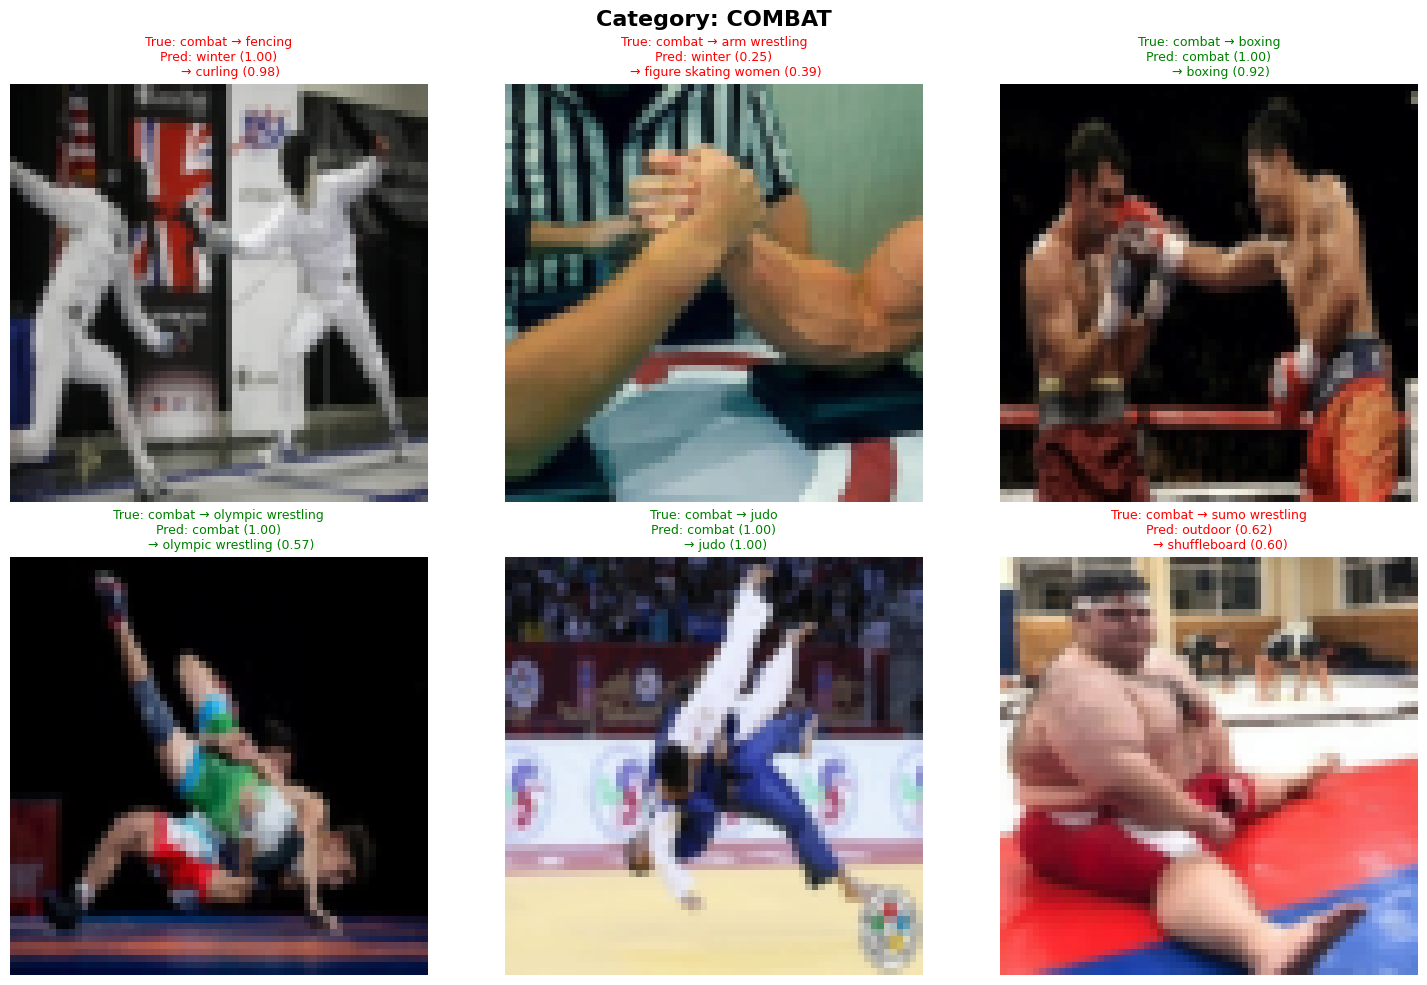

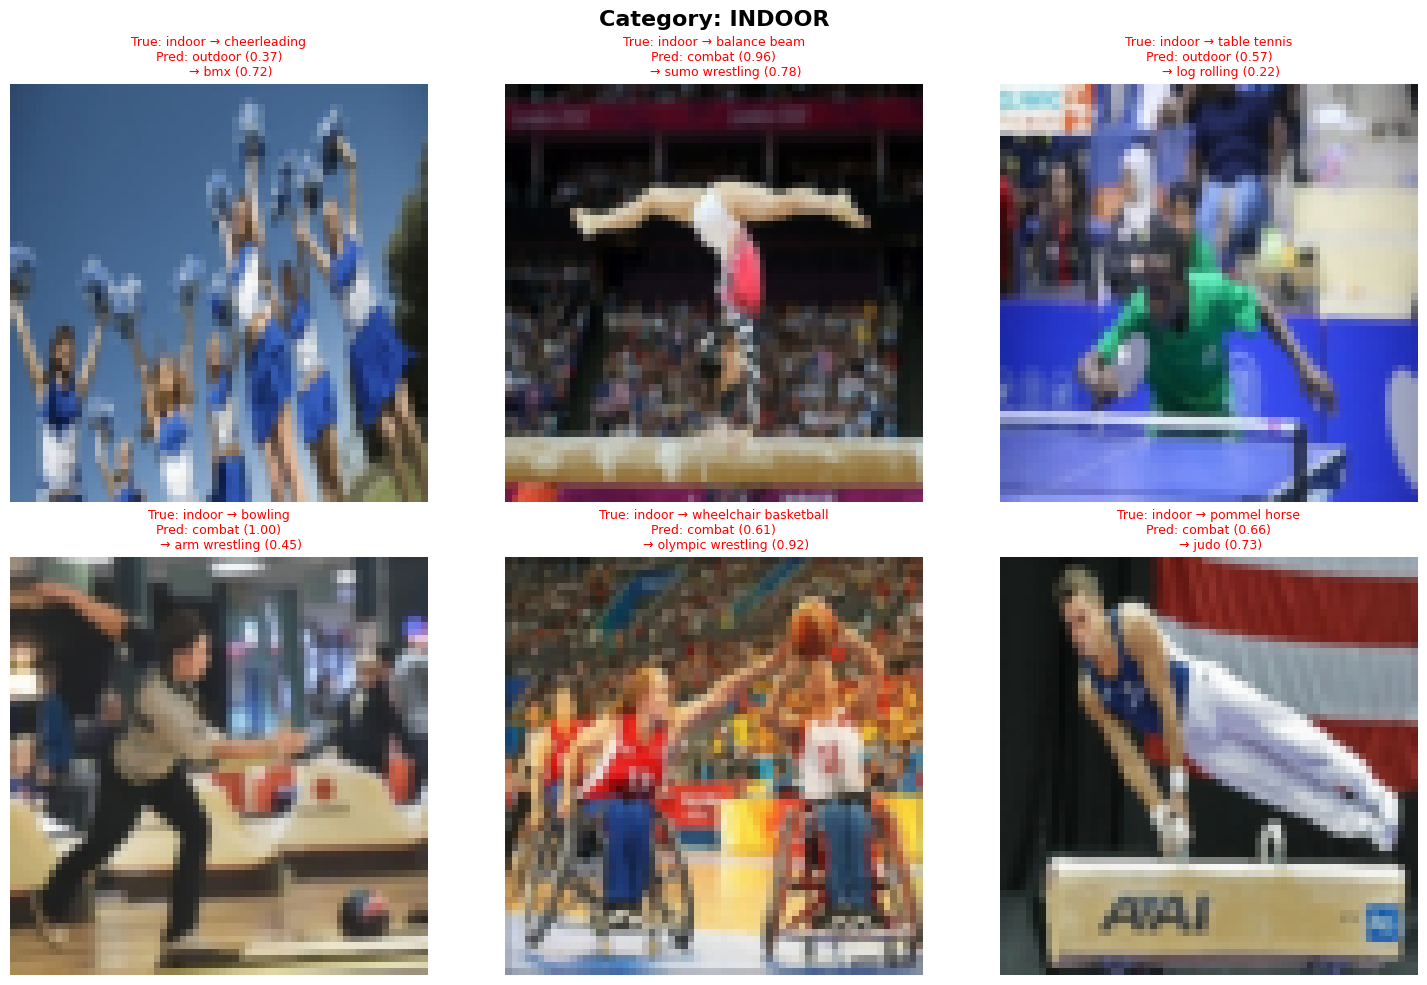

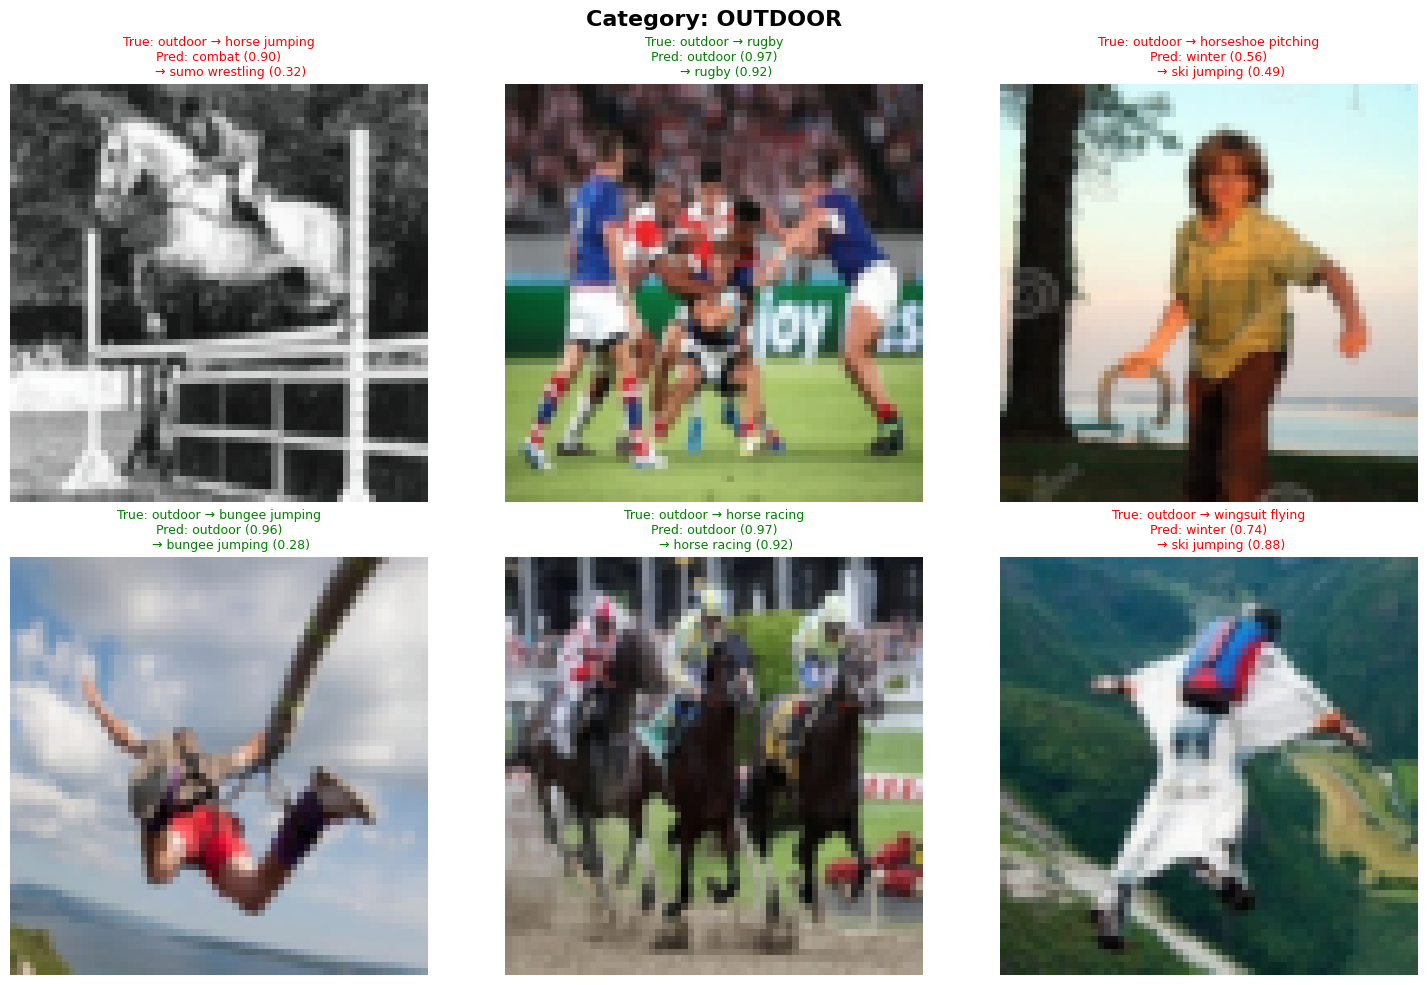

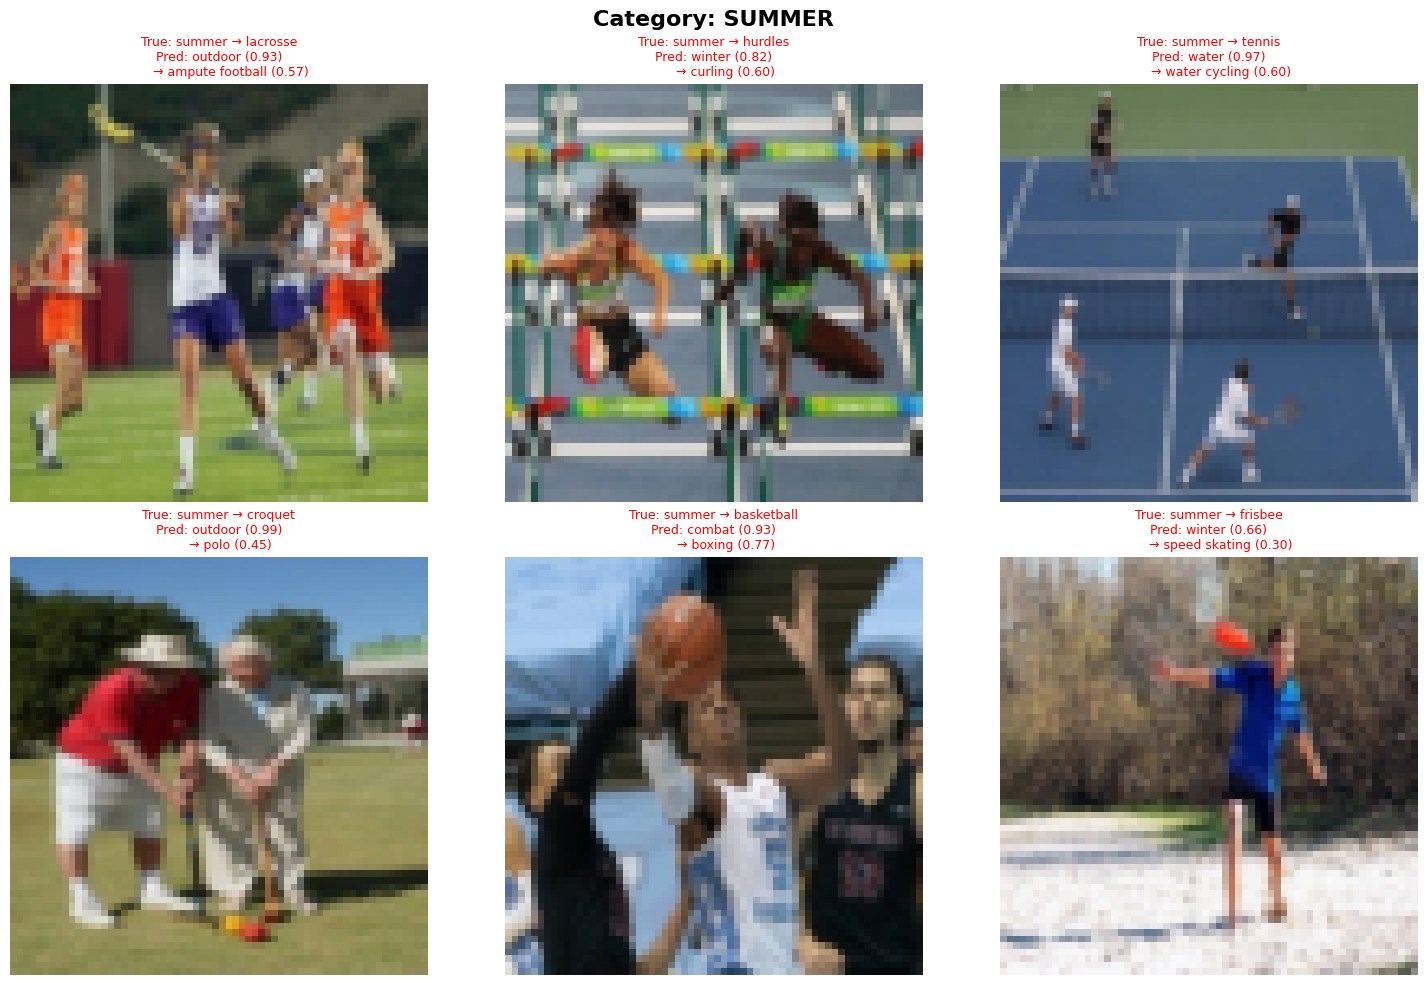

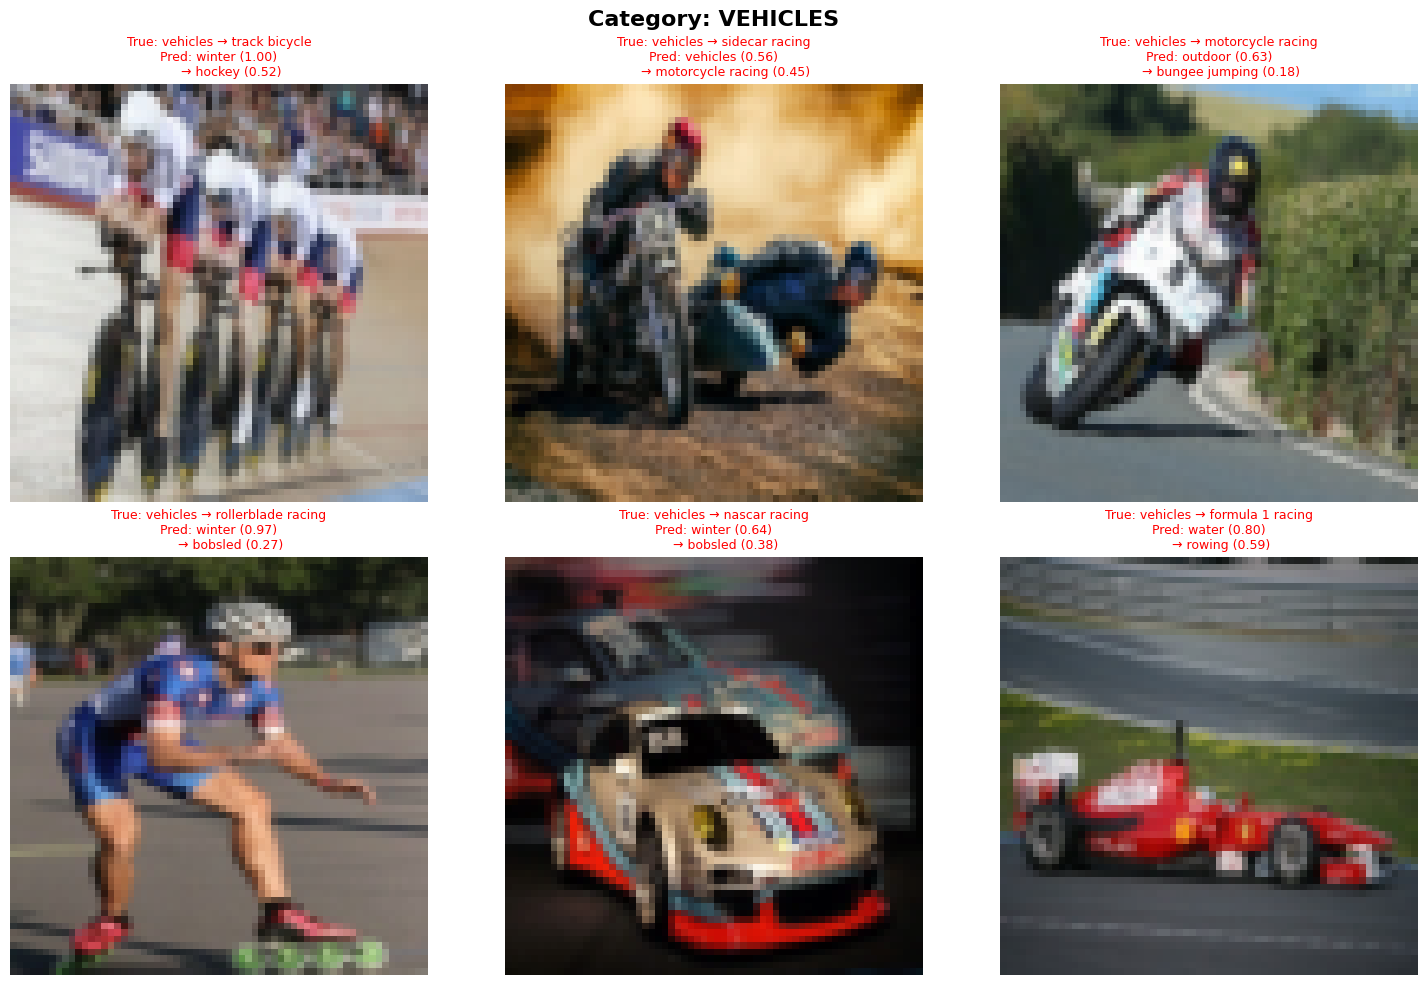

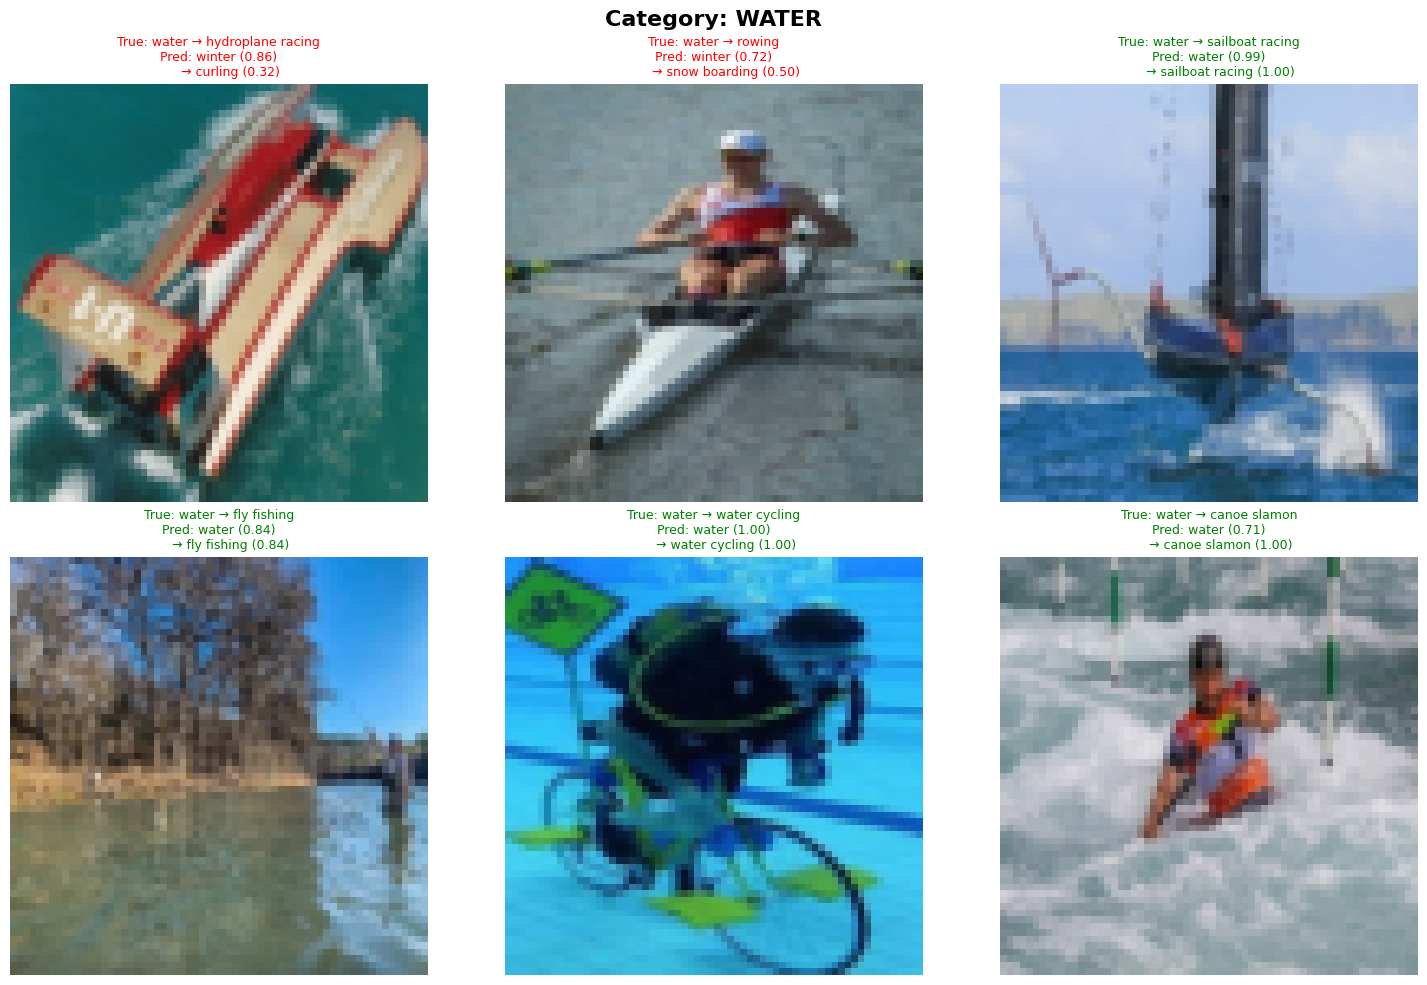

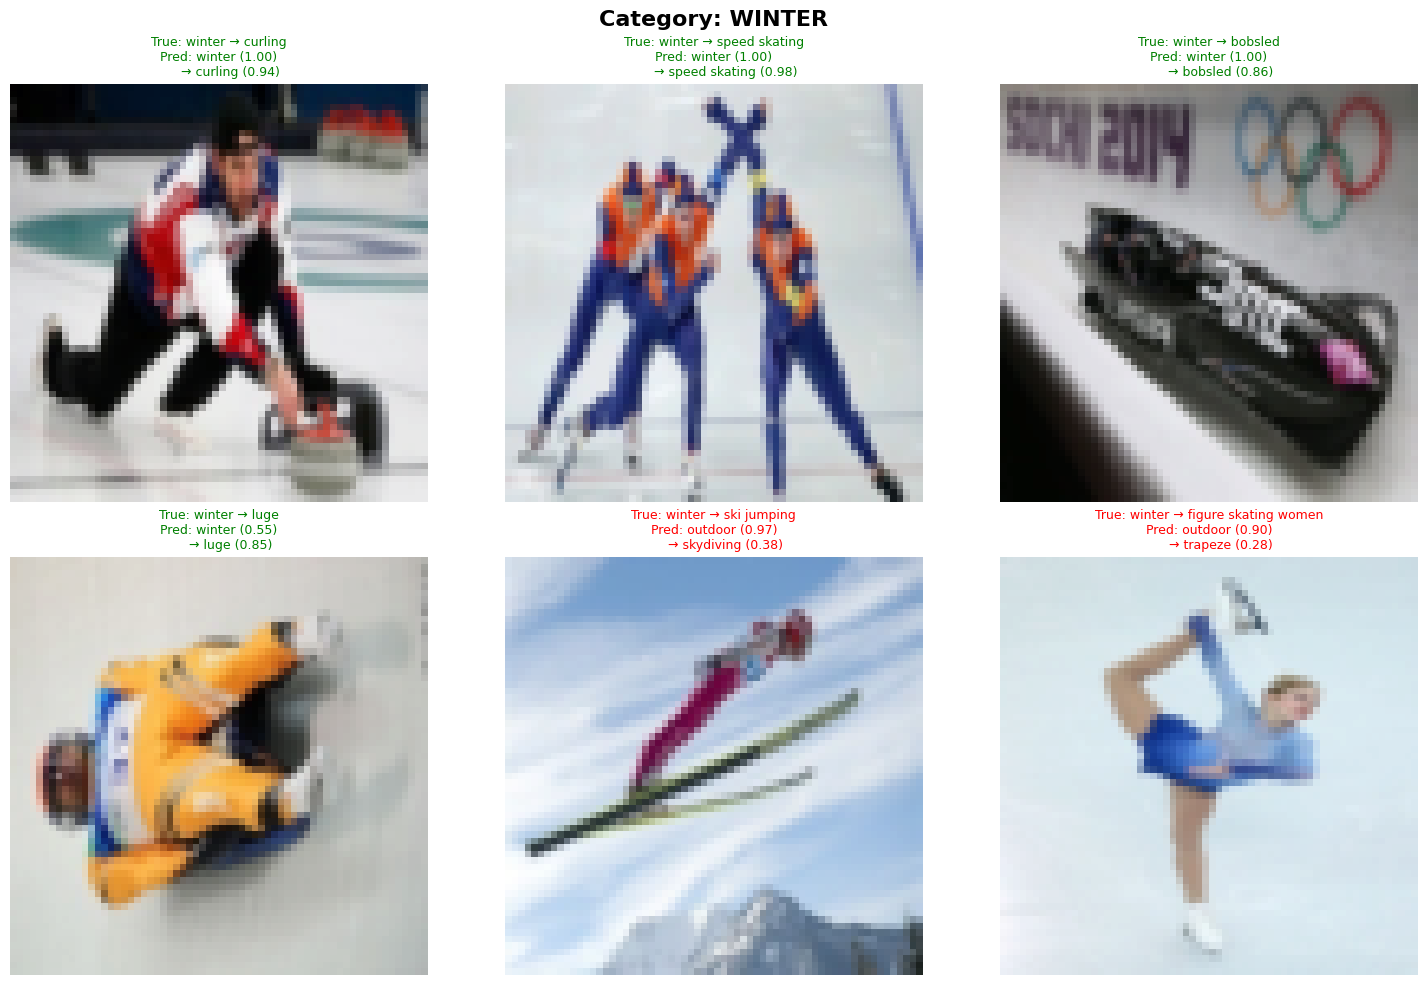

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Configuration
num_sports_per_category = 6
categories = test_base.category_classes

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Create 7 separate figures, one for each category
for category in categories:
    # Find all indices grouped by sport for this category
    sport_indices = {}  # {sport_name: [list of indices]}

    for idx in range(len(test_base)):
        _, cat_label, sport_label = test_base[idx]
        if test_base.category_classes[cat_label] == category:
            sport_name = test_base.sport_classes[sport_label]
            if sport_name not in sport_indices:
                sport_indices[sport_name] = []
            sport_indices[sport_name].append(idx)

    # Get list of unique sports in this category
    available_sports = list(sport_indices.keys())

    # Randomly select up to 6 unique sports
    num_to_sample = min(num_sports_per_category, len(available_sports))
    selected_sports = random.sample(available_sports, num_to_sample)

    # For each selected sport, pick one random image
    random_indices = []
    for sport in selected_sports:
        random_idx = random.choice(sport_indices[sport])
        random_indices.append(random_idx)

    # Create figure with 2 rows × 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    fig.suptitle(f"Category: {category.upper()}", fontsize=16, fontweight="bold")

    for i, random_idx in enumerate(random_indices):
        # Get test image
        test_image, true_cat_label, true_sport_label = test_base[random_idx]

        # Get true labels
        true_category = test_base.category_classes[true_cat_label]
        true_sport = test_base.sport_classes[true_sport_label]

        # Make prediction
        prediction = hierarchical_classifier.predict_single(test_image)

        # Denormalize image
        img_display = test_image.permute(1, 2, 0).numpy()
        img_display = img_display * std + mean
        img_display = np.clip(img_display, 0, 1)

        # Display
        axes[i].imshow(img_display)
        axes[i].axis("off")

        # Color code: green if correct, red if wrong
        cat_correct = prediction["category"] == true_category
        sport_correct = prediction["sport"] == true_sport

        title_color = "green" if (cat_correct and sport_correct) else "red"

        axes[i].set_title(
            f"True: {true_category} → {true_sport}\n"
            f"Pred: {prediction['category']} ({prediction['category_confidence']:.2f})\n"
            f"      → {prediction['sport']} ({prediction['sport_confidence']:.2f})",
            fontsize=9,
            color=title_color,
        )

    # Hide empty subplots if category has fewer than 6 unique sports
    for i in range(num_to_sample, 6):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


In [14]:
from torchinfo import summary
import torch

model = CustomCNN(num_classes=7, in_channels=3)

# Print detailed model summary
summary(
    model,
    input_size=(1, 3, 64, 64),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    verbose=1,
)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
CustomCNN                                [1, 3, 64, 64]            [1, 7]                    --                        --
├─Conv2d: 1-1                            [1, 3, 64, 64]            [1, 32, 64, 64]           896                       [3, 3]
├─BatchNorm2d: 1-2                       [1, 32, 64, 64]           [1, 32, 64, 64]           64                        --
├─MaxPool2d: 1-3                         [1, 32, 64, 64]           [1, 32, 32, 32]           --                        [2, 2]
├─Conv2d: 1-4                            [1, 32, 32, 32]           [1, 64, 32, 32]           18,496                    [3, 3]
├─BatchNorm2d: 1-5                       [1, 64, 32, 32]           [1, 64, 32, 32]           128                       --
├─MaxPool2d: 1-6                         [1, 64, 32, 32]           [1, 64, 16, 16]           --                        [2, 2

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
CustomCNN                                [1, 3, 64, 64]            [1, 7]                    --                        --
├─Conv2d: 1-1                            [1, 3, 64, 64]            [1, 32, 64, 64]           896                       [3, 3]
├─BatchNorm2d: 1-2                       [1, 32, 64, 64]           [1, 32, 64, 64]           64                        --
├─MaxPool2d: 1-3                         [1, 32, 64, 64]           [1, 32, 32, 32]           --                        [2, 2]
├─Conv2d: 1-4                            [1, 32, 32, 32]           [1, 64, 32, 32]           18,496                    [3, 3]
├─BatchNorm2d: 1-5                       [1, 64, 32, 32]           [1, 64, 32, 32]           128                       --
├─MaxPool2d: 1-6                         [1, 64, 32, 32]           [1, 64, 16, 16]           --                        [2, 2

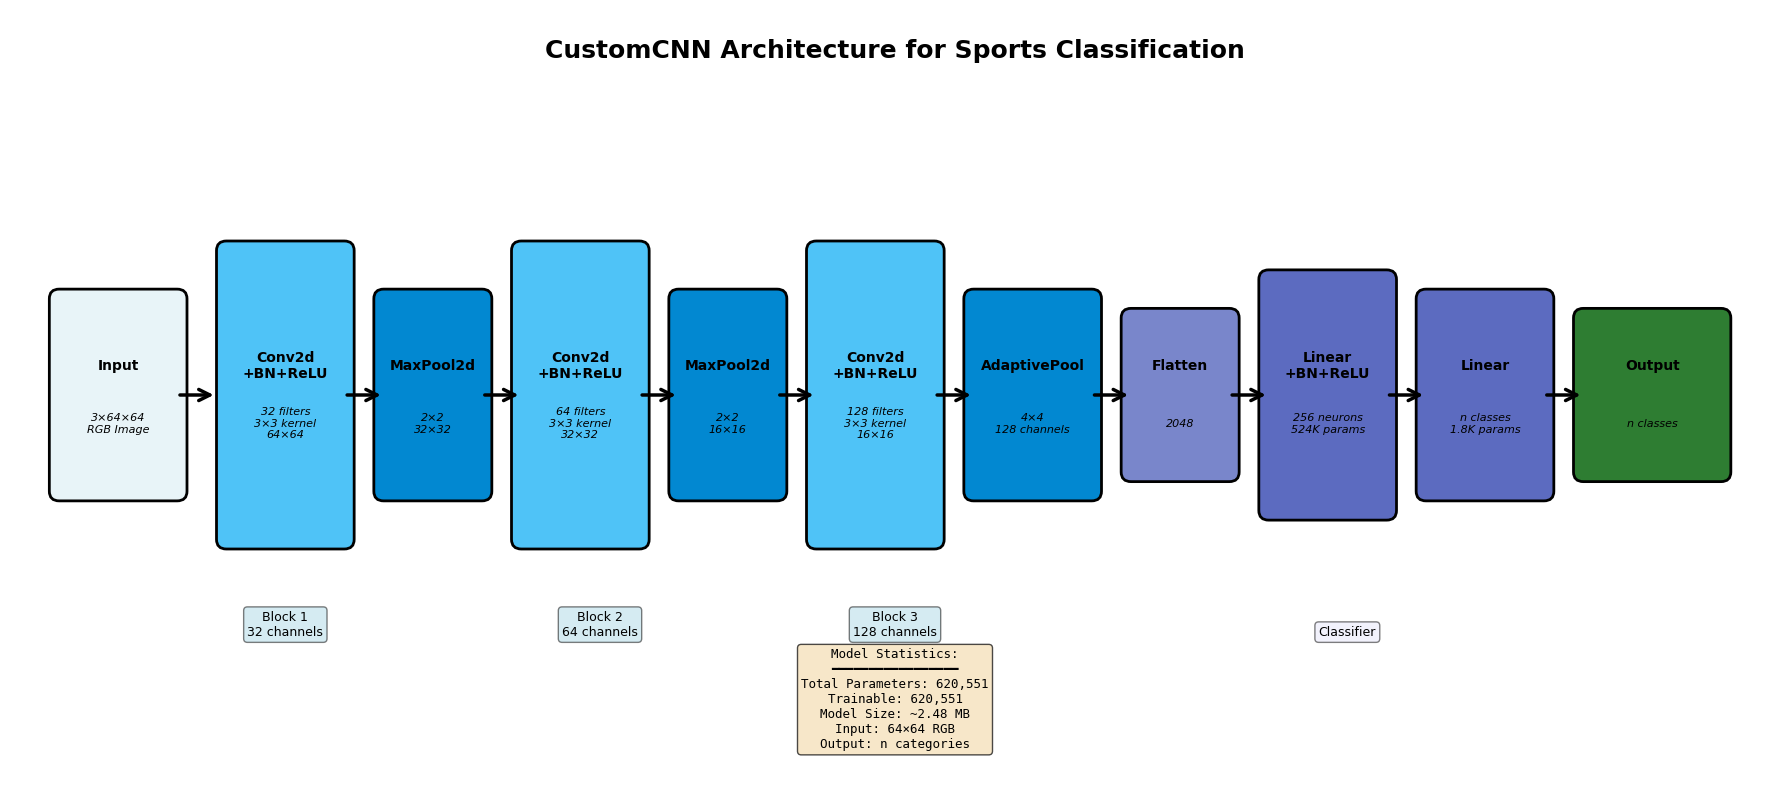

✓ Diagram saved as 'cnn_architecture_diagram.png'


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 18)
ax.set_ylim(0, 8)
ax.axis("off")

# Title
ax.text(
    9,
    7.5,
    "CustomCNN Architecture for Sports Classification",
    fontsize=18,
    fontweight="bold",
    ha="center",
)

# Define colors for different layer types
colors = {
    "input": "#E8F4F8",
    "conv": "#4FC3F7",
    "pool": "#0288D1",
    "flatten": "#7986CB",
    "fc": "#5C6BC0",
    "output": "#2E7D32",
}

# Layer information: (x, y, width, height, label, detail, color)
layers = [
    # Input
    (0.5, 3, 1.2, 2, "Input", "3×64×64\nRGB Image", colors["input"]),
    # Block 1
    (
        2.2,
        2.5,
        1.2,
        3,
        "Conv2d\n+BN+ReLU",
        "32 filters\n3×3 kernel\n64×64",
        colors["conv"],
    ),
    (3.8, 3, 1, 2, "MaxPool2d", "2×2\n32×32", colors["pool"]),
    # Block 2
    (
        5.2,
        2.5,
        1.2,
        3,
        "Conv2d\n+BN+ReLU",
        "64 filters\n3×3 kernel\n32×32",
        colors["conv"],
    ),
    (6.8, 3, 1, 2, "MaxPool2d", "2×2\n16×16", colors["pool"]),
    # Block 3
    (
        8.2,
        2.5,
        1.2,
        3,
        "Conv2d\n+BN+ReLU",
        "128 filters\n3×3 kernel\n16×16",
        colors["conv"],
    ),
    (9.8, 3, 1.2, 2, "AdaptivePool", "4×4\n128 channels", colors["pool"]),
    # Flatten
    (11.4, 3.2, 1, 1.6, "Flatten", "2048", colors["flatten"]),
    # FC layers
    (12.8, 2.8, 1.2, 2.4, "Linear\n+BN+ReLU", "256 neurons\n524K params", colors["fc"]),
    (14.4, 3, 1.2, 2, "Linear", "n classes\n1.8K params", colors["fc"]),
    # Output
    (16, 3.2, 1.4, 1.6, "Output", "n classes", colors["output"]),
]

# Draw all layers
for x, y, w, h, label, detail, color in layers:
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.1",
        edgecolor="black",
        facecolor=color,
        linewidth=2,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2 + 0.3,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
    ax.text(
        x + w / 2,
        y + h / 2 - 0.3,
        detail,
        ha="center",
        va="center",
        fontsize=8,
        style="italic",
    )

# Draw arrows between layers
arrow_coords = [
    (1.7, 4),
    (3.4, 4),
    (4.8, 4),
    (6.4, 4),
    (7.8, 4),
    (9.4, 4),
    (11.0, 4),
    (12.4, 4),
    (14.0, 4),
    (15.6, 4),
]

for x_start, y in arrow_coords:
    arrow = FancyArrowPatch(
        (x_start, y),
        (x_start + 0.4, y),
        arrowstyle="->",
        mutation_scale=20,
        linewidth=2.5,
        color="black",
    )
    ax.add_patch(arrow)

# Add annotations
ax.text(
    2.8,
    1.5,
    "Block 1\n32 channels",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5),
)
ax.text(
    6.0,
    1.5,
    "Block 2\n64 channels",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5),
)
ax.text(
    9.0,
    1.5,
    "Block 3\n128 channels",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5),
)
ax.text(
    13.6,
    1.5,
    "Classifier",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lavender", alpha=0.5),
)

# Add model statistics
stats_text = (
    "Model Statistics:\n"
    "━━━━━━━━━━━━━━━━━\n"
    "Total Parameters: 620,551\n"
    "Trainable: 620,551\n"
    "Model Size: ~2.48 MB\n"
    "Input: 64×64 RGB\n"
    "Output: n categories"
)
ax.text(
    9,
    0.3,
    stats_text,
    ha="center",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
    family="monospace",
)

plt.tight_layout()
plt.savefig(
    "cnn_architecture_diagram.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()

print("✓ Diagram saved as 'cnn_architecture_diagram.png'")
